In [2]:
# --- Cell 1: Imports, load POUS, identify the longest event, load CONUS county geometries ---

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
import pyarrow.dataset as ds

# File paths
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
out_gif_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\longest_event_conus_animation.gif"

# Load raw POUS event table
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Identify the longest-duration county-event
longest = pous.loc[pous["duration_hours"].idxmax()].copy()

selected_county = str(longest["CountyFIPS"]).zfill(5)
selected_event_start = pd.Timestamp(longest["event_start"])
selected_duration_hours = int(longest["duration_hours"])
selected_event_end = selected_event_start + pd.Timedelta(hours=selected_duration_hours)

print("Longest event selected:")
print(f"CountyFIPS: {selected_county}")
print(f"Storm:      {longest['storm']}")
print(f"Start:      {selected_event_start}")
print(f"Duration:   {selected_duration_hours} hours")
print(f"End:        {selected_event_end}")

# Load county geometries for CONUS
counties = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip")
counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]
counties = counties[["CountyFIPS", "NAME", "geometry"]].copy()

print("\nCounty geometry shape:", counties.shape)
print("Matched selected county:", counties[counties["CountyFIPS"] == selected_county][["CountyFIPS", "NAME"]].head())

# Load parquet dataset for filtered time-series access
ts_dataset = ds.dataset(ts_path, format="parquet")
print("\nParquet schema:", ts_dataset.schema.names)

Longest event selected:
CountyFIPS: 22011
Storm:      2020233N14313
Start:      2020-08-27 06:00:00
Duration:   807 hours
End:        2020-09-29 21:00:00

County geometry shape: (3234, 3)
Matched selected county:      CountyFIPS        NAME
3126      22011  Beauregard

Parquet schema: ['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']


In [9]:
# --- Cell 2: Load the selected county's time series and prepare hourly frames ---

def load_county_window(county_fips, window_start, window_end):
    """
    Load a filtered time window for a single county directly from the large parquet file.
    """
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= pd.Timestamp(window_start).to_pydatetime()) &
        (ds.field("RecordDateTime") <= pd.Timestamp(window_end).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()
    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# Add a little padding so the animation shows some context before/after the event
pad_hours_before = 12
pad_hours_after = 12

window_start = selected_event_start - pd.Timedelta(hours=pad_hours_before)
window_end = selected_event_end + pd.Timedelta(hours=pad_hours_after)

county_ts = load_county_window(selected_county, window_start, window_end)

print("Loaded county time series shape:", county_ts.shape)
print(county_ts.head().to_string(index=False))

# Create the full hourly frame index for the animation
frame_times = pd.date_range(window_start, window_end, freq="h")

# Merge to ensure every frame has a value, filling missing hours with zero outage
frame_df = pd.DataFrame({"RecordDateTime": frame_times})
frame_df = frame_df.merge(
    county_ts[["RecordDateTime", "OutageFraction"]],
    on="RecordDateTime",
    how="left"
)
frame_df["OutageFraction"] = frame_df["OutageFraction"].fillna(0.0)

print("\nFrame table shape:", frame_df.shape)
print(frame_df.head().to_string(index=False))

Loaded county time series shape: (832, 3)
     RecordDateTime CountyFIPS  OutageFraction
2020-08-26 18:00:00      22011        0.000135
2020-08-26 19:00:00      22011        0.002434
2020-08-26 20:00:00      22011        0.002479
2020-08-26 21:00:00      22011        0.007076
2020-08-26 22:00:00      22011        0.007076

Frame table shape: (832, 2)
     RecordDateTime  OutageFraction
2020-08-26 18:00:00        0.000135
2020-08-26 19:00:00        0.002434
2020-08-26 20:00:00        0.002479
2020-08-26 21:00:00        0.007076
2020-08-26 22:00:00        0.007076


# --- Cell 3: Build and save the animation (CONUS county map, county-event prototype) ---

from matplotlib.colors import LinearSegmentedColormap

# White -> red heatmap for outage fraction
cmap = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#cb181d"]
)

# Precompute county geometry boundaries for the background map
county_bounds = counties.copy()

# Figure setup
fig, ax = plt.subplots(figsize=(14, 10))

def update(frame_idx):
    ax.clear()

    current_time = frame_times[frame_idx]
    current_outage = float(frame_df.loc[frame_df["RecordDateTime"] == current_time, "OutageFraction"].iloc[0])

    # Background: all CONUS county boundaries in light gray
    county_bounds.boundary.plot(ax=ax, linewidth=0.15, color="lightgray")

    # Fill all counties white first
    counties.assign(outage=0.0).plot(
        ax=ax,
        column="outage",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        linewidth=0.0,
        edgecolor=None
    )

    # Highlight the selected county with its current outage fraction
    current_county = counties[counties["CountyFIPS"] == selected_county].copy()
    current_county["outage"] = current_outage

    current_county.plot(
        ax=ax,
        column="outage",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        linewidth=0.8,
        edgecolor="black"
    )

    ax.set_title(
        f"Longest-duration event animation | County {selected_county} | "
        f"{current_time:%Y-%m-%d %H:%M} | outage={current_outage:.3f}"
    )
    ax.set_axis_off()

# Build animation
anim = FuncAnimation(
    fig,
    update,
    frames=len(frame_times),
    interval=200,
    repeat=False
)

# Save as GIF
anim.save(out_gif_path, writer=PillowWriter(fps=5))

plt.close(fig)

print("Saved animation to:")
print(out_gif_path)

# --- Choropleth animation with early stop option ---

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
import pyarrow.dataset as ds

# -----------------------
# Settings
# -----------------------
MAX_FRAMES = 15      # set to None to run all frames
FPS = 5

pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
out_gif_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\choropleth_test.gif"

# -----------------------
# Load POUS and select one event to animate
# -----------------------
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Longest event as a test case
evt = pous.loc[pous["duration_hours"].idxmax()].copy()
county_fips = str(evt["CountyFIPS"]).zfill(5)
event_start = pd.Timestamp(evt["event_start"])
duration_hours = int(evt["duration_hours"])
event_end = event_start + pd.Timedelta(hours=duration_hours)

print("Selected event:")
print(evt[["storm", "CountyFIPS", "event_start", "duration_hours"]])

# -----------------------
# Load county geometries and parquet dataset
# -----------------------
counties = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip")
counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]
counties = counties[["CountyFIPS", "NAME", "geometry"]].copy()

ts_dataset = ds.dataset(ts_path, format="parquet")

def load_county_window(county_fips, window_start, window_end):
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= pd.Timestamp(window_start).to_pydatetime()) &
        (ds.field("RecordDateTime") <= pd.Timestamp(window_end).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )
    out = table.to_pandas()

    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    return out.sort_values("RecordDateTime").reset_index(drop=True)

# -----------------------
# Load county time series for the selected county-event
# -----------------------
pad_before_hours = 12
pad_after_hours = 12

window_start = event_start - pd.Timedelta(hours=pad_before_hours)
window_end = event_end + pd.Timedelta(hours=pad_after_hours)

county_ts = load_county_window(county_fips, window_start, window_end)
print("Loaded county_ts:", county_ts.shape)

# Frame timestamps
frame_times = pd.date_range(window_start, window_end, freq="h")
if MAX_FRAMES is not None:
    frame_times = frame_times[:MAX_FRAMES]

# Merge to ensure a value for each frame
frame_df = pd.DataFrame({"RecordDateTime": frame_times})
frame_df = frame_df.merge(
    county_ts[["RecordDateTime", "OutageFraction"]],
    on="RecordDateTime",
    how="left"
)
frame_df["OutageFraction"] = frame_df["OutageFraction"].fillna(0.0)

# -----------------------
# Plot setup
# -----------------------
cmap = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#cb181d"]
)

fig, ax = plt.subplots(figsize=(14, 10))

# Precompute a background map once
county_boundary = counties.boundary

def update(frame_idx):
    ax.clear()

    current_time = frame_times[frame_idx]
    current_outage = float(frame_df.loc[frame_df["RecordDateTime"] == current_time, "OutageFraction"].iloc[0])

    # Build a county-level table for this frame:
    # all counties = 0, selected county = current outage
    frame_gdf = counties.copy()
    frame_gdf["outage"] = 0.0
    frame_gdf.loc[frame_gdf["CountyFIPS"] == county_fips, "outage"] = current_outage

    frame_gdf.plot(
        ax=ax,
        column="outage",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        linewidth=0.0,
        edgecolor=None
    )

    county_boundary.plot(ax=ax, linewidth=0.15, color="lightgray")

    ax.set_title(
        f"Choropleth test | {evt['storm']} | {county_fips} | "
        f"{current_time:%Y-%m-%d %H:%M} | outage={current_outage:.3f}"
    )
    ax.set_axis_off()

anim = FuncAnimation(fig, update, frames=len(frame_times), interval=200, repeat=False)

anim.save(out_gif_path, writer=PillowWriter(fps=FPS))
plt.close(fig)

print("Saved:", out_gif_path)
print("Frames rendered:", len(frame_times))

In [11]:
# --- Choropleth animation with simplified CONUS counties and early stop option ---

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
import pyarrow.dataset as ds

# -----------------------
# Settings
# -----------------------
MAX_FRAMES = 10      # set to None to render all frames
FPS = 5

pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
out_gif_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\choropleth_test.gif"

# Geometry simplification tolerance in meters (larger = faster, less detailed)
SIMPLIFY_TOLERANCE_M = 5000

# Exclude non-CONUS states/territories
# Keep lower 48 + DC
EXCLUDE_STATEFPS = {"02", "15", "60", "66", "69", "72", "78"}

# -----------------------
# Load POUS and select one event to animate
# -----------------------
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Use the longest-duration event as a test case
evt = pous.loc[pous["duration_hours"].idxmax()].copy()
county_fips = str(evt["CountyFIPS"]).zfill(5)
event_start = pd.Timestamp(evt["event_start"])
duration_hours = int(evt["duration_hours"])
event_end = event_start + pd.Timedelta(hours=duration_hours)

print("Selected event:")
print(evt[["storm", "CountyFIPS", "event_start", "duration_hours"]])

# -----------------------
# Load county geometries and keep only CONUS
# -----------------------
counties = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip")
counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]

# Keep only CONUS counties
counties = counties[~counties["STATEFP"].isin(EXCLUDE_STATEFPS)].copy()

# Reproject to CONUS Albers for faster/saner simplification
counties = counties.to_crs(epsg=5070)

# Simplify geometries to reduce plotting cost
counties["geometry"] = counties.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M,
    preserve_topology=True
)

# Keep only the columns needed for plotting
counties = counties[["CountyFIPS", "NAME", "geometry"]].copy()

print("CONUS counties shape:", counties.shape)
print("Selected county match:")
print(counties[counties["CountyFIPS"] == county_fips][["CountyFIPS", "NAME"]].head())

# -----------------------
# Load parquet dataset for filtered time-series access
# -----------------------
ts_dataset = ds.dataset(ts_path, format="parquet")

def load_county_window(county_fips, window_start, window_end):
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= pd.Timestamp(window_start).to_pydatetime()) &
        (ds.field("RecordDateTime") <= pd.Timestamp(window_end).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()
    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)

    return out

# -----------------------
# Load county time series for the selected event
# -----------------------
pad_hours_before = 12
pad_hours_after = 12

window_start = event_start - pd.Timedelta(hours=pad_hours_before)
window_end = event_end + pd.Timedelta(hours=pad_hours_after)

county_ts = load_county_window(county_fips, window_start, window_end)
print("Loaded county_ts:", county_ts.shape)

# Frame timestamps
frame_times = pd.date_range(window_start, window_end, freq="h")
if MAX_FRAMES is not None:
    frame_times = frame_times[:MAX_FRAMES]

# Merge to ensure a value for each frame
frame_df = pd.DataFrame({"RecordDateTime": frame_times})
frame_df = frame_df.merge(
    county_ts[["RecordDateTime", "OutageFraction"]],
    on="RecordDateTime",
    how="left"
)
frame_df["OutageFraction"] = frame_df["OutageFraction"].fillna(0.0)

# -----------------------
# Plot setup
# -----------------------
cmap = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#cb181d"]
)

fig, ax = plt.subplots(figsize=(14, 10))

# Precompute a blank county layer once
base_gdf = counties.copy()
base_gdf["outage"] = 0.0

def update(frame_idx):
    ax.clear()

    current_time = frame_times[frame_idx]
    current_outage = float(
        frame_df.loc[frame_df["RecordDateTime"] == current_time, "OutageFraction"].iloc[0]
    )

    # All counties white by default
    frame_gdf = base_gdf.copy()
    frame_gdf.loc[frame_gdf["CountyFIPS"] == county_fips, "outage"] = current_outage

    frame_gdf.plot(
        ax=ax,
        column="outage",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        linewidth=0.0,
        edgecolor=None
    )

    ax.set_title(
        f"CONUS choropleth test | {evt['storm']} | {county_fips} | "
        f"{current_time:%Y-%m-%d %H:%M} | outage={current_outage:.3f}"
    )
    ax.set_axis_off()

anim = FuncAnimation(
    fig,
    update,
    frames=len(frame_times),
    interval=200,
    repeat=False
)

anim.save(out_gif_path, writer=PillowWriter(fps=FPS))
plt.close(fig)

print("Saved:", out_gif_path)
print("Frames rendered:", len(frame_times))

Selected event:
storm                   2020233N14313
CountyFIPS                      22011
event_start       2020-08-27 06:00:00
duration_hours                    807
Name: 621, dtype: object
CONUS counties shape: (3108, 3)
Selected county match:
     CountyFIPS        NAME
3126      22011  Beauregard
Loaded county_ts: (832, 3)
Saved: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\choropleth_test.gif
Frames rendered: 10


Not working so let's try a static frame:

Loaded hourly rows: (3035, 3)
     RecordDateTime CountyFIPS  OutageFraction
2020-08-26 23:00:00      01001        0.000000
2020-08-26 23:00:00      01003        0.000010
2020-08-26 23:00:00      01005        0.000367
2020-08-26 23:00:00      01007        0.000347
2020-08-26 23:00:00      01009        0.000000


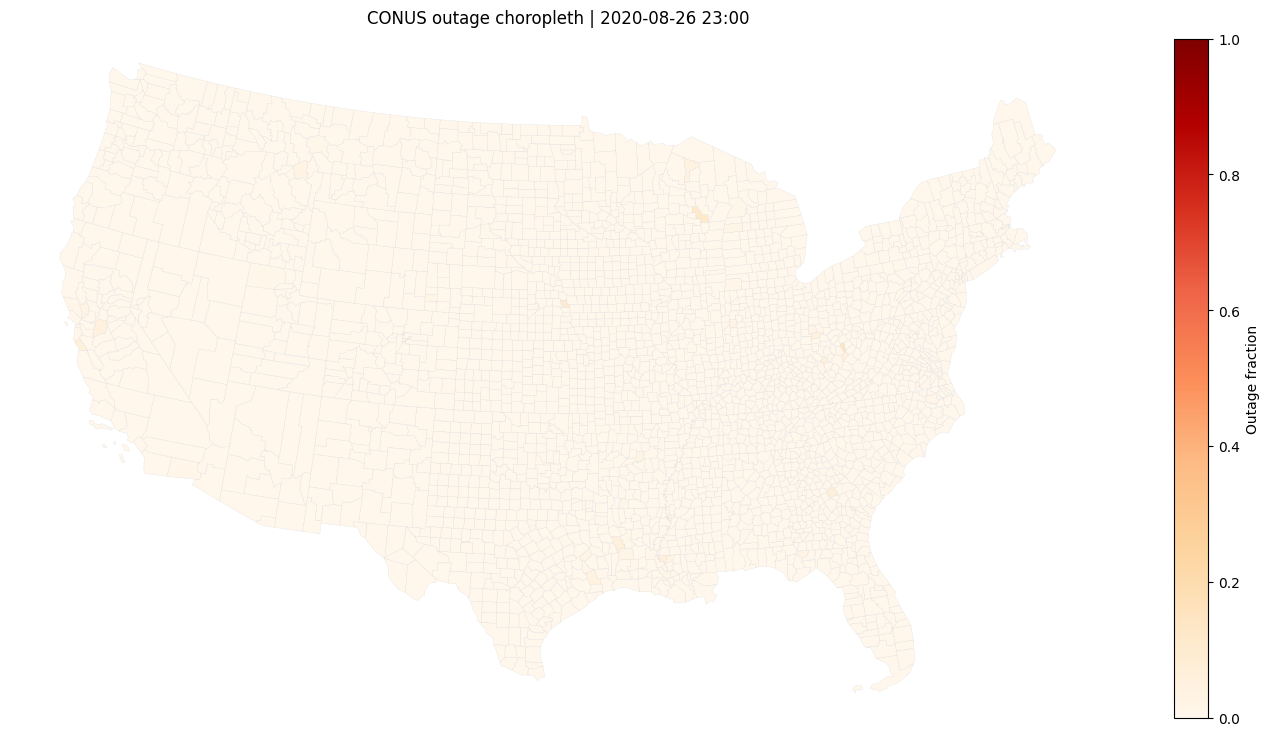

In [14]:
# --- Static CONUS choropleth test at one hour ---

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

# Assumes these already exist in the notebook:
# - ts_dataset
# - counties  (CONUS counties GeoDataFrame)
# - frame_times (hourly times for the selected event window)

def load_hourly_conus(frame_time):
    """
    Load outage fraction for all counties at a single hourly timestamp.
    """
    frame_time = pd.Timestamp(frame_time)

    filt = (
        (ds.field("RecordDateTime") >= frame_time.to_pydatetime()) &
        (ds.field("RecordDateTime") < (frame_time + pd.Timedelta(hours=1)).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()
    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    return out

# Pick the midpoint hour of the current event window
mid_time = frame_times[len(frame_times) // 2]

# Load all counties for that hour
hour_df = load_hourly_conus(mid_time)

print("Loaded hourly rows:", hour_df.shape)
print(hour_df.head().to_string(index=False))

# Merge outage values onto county polygons
plot_gdf = counties.merge(hour_df[["CountyFIPS", "OutageFraction"]], on="CountyFIPS", how="left")

# Fill any missing counties as no outage
plot_gdf["OutageFraction"] = plot_gdf["OutageFraction"].fillna(0.0)

# Plot CONUS choropleth
fig, ax = plt.subplots(figsize=(14, 10))

plot_gdf.plot(
    ax=ax,
    column="OutageFraction",
    cmap="OrRd",
    vmin=0.0,
    vmax=1.0,
    linewidth=0.15,
    edgecolor="lightgray",
    legend=True,
    legend_kwds={"label": "Outage fraction", "shrink": 0.7}
)

ax.set_title(f"CONUS outage choropleth | {mid_time:%Y-%m-%d %H:%M}")
ax.set_axis_off()

plt.tight_layout()
plt.show()

^ not bad but i don't want yellow for 0.0

# --- Cell 1: Setup for a storm-wide CONUS choropleth animation test ---

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib import cm

# -----------------------
# Paths and settings
# -----------------------
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv"
ts_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"
out_gif_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\choropleth_stormwide_test.gif"

MAX_FRAMES = 20          # set to None for the full storm window
FPS = 5
PAD_HOURS_BEFORE = 12
PAD_HOURS_AFTER = 12
SIMPLIFY_TOLERANCE_M = 5000

# Keep lower 48 + DC; exclude Alaska/Hawaii/territories
EXCLUDE_STATEFPS = {"02", "15", "60", "66", "69", "72", "78"}

# -----------------------
# Load POUS and select a test storm
# -----------------------
pous = pd.read_csv(pous_path)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

# Use the storm from the longest-duration POUS event as a test case
storm_id = str(pous.loc[pous["duration_hours"].idxmax(), "storm"])
storm_events = (
    pous[pous["storm"] == storm_id]
    .copy()
    .sort_values(["event_start", "CountyFIPS"])
    .reset_index(drop=True)
)

print("Selected storm:", storm_id)
print("Affected counties:", storm_events["CountyFIPS"].nunique())
print("\nAffected county-event rows:")
print(storm_events[["CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

# -----------------------
# Load CONUS counties and simplify geometry
# -----------------------
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]
counties = counties[~counties["STATEFP"].isin(EXCLUDE_STATEFPS)].copy()
counties = counties.to_crs(epsg=5070)
counties["geometry"] = counties.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M,
    preserve_topology=True
)
counties = counties[["CountyFIPS", "NAME", "geometry"]].copy()

print("\nCounty geometry shape:", counties.shape)

# -----------------------
# Parquet dataset access
# -----------------------
ts_dataset = ds.dataset(ts_path, format="parquet")

def load_county_window(county_fips, window_start, window_end):
    """
    Load a small county-level time window directly from the large parquet file.
    """
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= pd.Timestamp(window_start).to_pydatetime()) &
        (ds.field("RecordDateTime") <= pd.Timestamp(window_end).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()
    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)
    return out

WORKING:

In [29]:
# --- Storm-wide CONUS choropleth animation test (fixed to show actual spatial outages) ---

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib import cm

# Assumes these already exist from earlier cells:
#   pous
#   counties
#   ts_dataset
#   load_county_window

from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm

# White at exactly 0.0, then visible colours for positive values
cmap = LinearSegmentedColormap.from_list(
    "white_yellow_red",
    ["#ffffff", "#ffffb2", "#fecc5c", "#fd8d3c", "#bd0026"]
)

# PowerNorm helps small positive outages show up more clearly
vmax = float(np.nanmax(storm_matrix.to_numpy()))
vmax = max(vmax, 0.05)
norm = PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax)

MAX_FRAMES = None # # or None
FPS = 8 # key parameter to change speed
PAD_HOURS_BEFORE = 12
PAD_HOURS_AFTER = 12
SIMPLIFY_TOLERANCE_M = 8000

out_gif_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\choropleth_stormwide_test.gif"

# Keep lower 48 + DC; exclude Alaska/Hawaii/territories
EXCLUDE_STATEFPS = {"02", "15", "60", "66", "69", "72", "78"}

# -----------------------
# Choose a storm that actually affects many counties
# -----------------------
pous = pous.copy()
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)
pous["event_start"] = pd.to_datetime(pous["event_start"])

storm_counts = pous.groupby("storm")["CountyFIPS"].nunique().sort_values(ascending=False)
storm_id = storm_counts.index[0]

storm_events = (
    pous[pous["storm"] == storm_id]
    .copy()
    .sort_values(["event_start", "CountyFIPS"])
    .reset_index(drop=True)
)

print("Selected storm:", storm_id)
print("Unique counties in storm:", storm_events["CountyFIPS"].nunique())
print("\nCounty-event rows:")
print(storm_events[["CountyFIPS", "event_start", "duration_hours"]].to_string(index=False))

# -----------------------
# Load CONUS counties and simplify geometry
# -----------------------
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = counties["STATEFP"] + counties["COUNTYFP"]
counties = counties[~counties["STATEFP"].isin(EXCLUDE_STATEFPS)].copy()
counties = counties.to_crs(epsg=5070)
counties["geometry"] = counties.geometry.simplify(
    tolerance=SIMPLIFY_TOLERANCE_M,
    preserve_topology=True
)
counties = counties[["CountyFIPS", "NAME", "geometry"]].copy()

print("\nCounty geometry shape:", counties.shape)

# -----------------------
# Build a county-hour outage lookup for the selected storm
# -----------------------
ts_dataset = ds.dataset(ts_path, format="parquet")

def load_county_window(county_fips, window_start, window_end):
    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= pd.Timestamp(window_start).to_pydatetime()) &
        (ds.field("RecordDateTime") <= pd.Timestamp(window_end).to_pydatetime())
    )

    table = ts_dataset.to_table(
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction"],
        filter=filt
    )

    out = table.to_pandas()
    if out.empty:
        return out

    if "RecordDateTime" not in out.columns or "CountyFIPS" not in out.columns:
        out = out.reset_index()

    out["RecordDateTime"] = pd.to_datetime(out["RecordDateTime"])
    out["CountyFIPS"] = out["CountyFIPS"].astype(str).str.zfill(5)
    out = out.sort_values("RecordDateTime").reset_index(drop=True)
    return out

county_lookup = {}

for county_fips, g in storm_events.groupby("CountyFIPS"):
    county_start = g["event_start"].min() - pd.Timedelta(hours=PAD_HOURS_BEFORE)
    county_end = (
        g["event_start"] + pd.to_timedelta(g["duration_hours"], unit="h")
    ).max() + pd.Timedelta(hours=PAD_HOURS_AFTER)

    ts = load_county_window(county_fips, county_start, county_end)

    if ts.empty:
        continue

    s = (
        ts.set_index("RecordDateTime")["OutageFraction"]
        .astype(float)
        .sort_index()
    )

    county_lookup[county_fips] = s

print("\nLoaded outage series for counties:", len(county_lookup))

# -----------------------
# Frame grid: start 1 hour before the first event in the storm
# -----------------------
global_start = storm_events["event_start"].min() - pd.Timedelta(hours=1)
global_end = (
    storm_events["event_start"] + pd.to_timedelta(storm_events["duration_hours"], unit="h")
).max() + pd.Timedelta(hours=PAD_HOURS_AFTER)

all_times = pd.date_range(global_start, global_end, freq="h")

# Reindex all county series to the same hourly grid so lookups are exact
for county_fips in list(county_lookup.keys()):
    county_lookup[county_fips] = county_lookup[county_fips].reindex(all_times, fill_value=0.0)

storm_matrix = pd.concat(county_lookup, axis=1).fillna(0.0)
storm_matrix.index = pd.DatetimeIndex(storm_matrix.index)

# Preview from the start of the event window
if MAX_FRAMES is not None:
    frame_times = storm_matrix.index[:MAX_FRAMES]
else:
    frame_times = storm_matrix.index

storm_matrix = storm_matrix.loc[frame_times]

print("Frames to render:", len(frame_times))
print("Frame window:", frame_times.min(), "to", frame_times.max())

# -----------------------
# Plot setup
# -----------------------
cmap = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#cb181d"]
)

# Stretch colours to the storm's own range so outages are visible
vmax = float(np.nanmax(storm_matrix.to_numpy()))
vmax = max(vmax, 0.05)
norm = Normalize(vmin=0.0, vmax=vmax)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[20, 1], wspace=0.02)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_label("Outage fraction")

def update(frame_idx):
    ax.clear()

    current_time = frame_times[frame_idx]
    current_vals = storm_matrix.loc[current_time]
    current_max_outage = float(np.nanmax(current_vals.to_numpy()))

    frame_out = pd.DataFrame({
        "CountyFIPS": current_vals.index.astype(str),
        "outage": current_vals.values.astype(float)
    })

    plot_gdf = counties.merge(frame_out, on="CountyFIPS", how="left")
    plot_gdf["outage"] = plot_gdf["outage"].fillna(0.0)

    # Make zero outage display as pure white
    plot_gdf["outage_plot"] = plot_gdf["outage"].where(plot_gdf["outage"] > 0, np.nan)

    plot_gdf.plot(
        ax=ax,
        column="outage_plot",
        cmap=cmap,
        norm=norm,
        linewidth=0.15,
        edgecolor="dimgray",
        legend=False,
        missing_kwds={"color": "white"}
    )

    ax.set_title(f"{current_time:%Y-%m-%d %H:%M}", fontsize=14)

    ax.text(
        0.02, 0.98,
        f"Storm ID: {storm_id}\n"
        f"Frame: {frame_idx + 1}/{len(frame_times)}\n"
        f"Map max outage: {current_max_outage:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.set_axis_off()

anim = FuncAnimation(
    fig,
    update,
    frames=len(frame_times),
    interval=200,
    repeat=False
)

anim.save(out_gif_path, writer=PillowWriter(fps=FPS))
plt.close(fig)

print("\nSaved animation to:")
print(out_gif_path)

Selected storm: 2018280N18273
Unique counties in storm: 161

County-event rows:
CountyFIPS         event_start  duration_hours
     12063 2018-10-09 00:00:00             553
     45089 2018-10-09 19:00:00              56
     45027 2018-10-09 23:00:00              45
     13153 2018-10-10 01:00:00              65
     37049 2018-10-10 05:00:00              58
     37013 2018-10-10 06:00:00              61
     12077 2018-10-10 13:00:00             388
     12129 2018-10-10 13:00:00             156
     13095 2018-10-10 14:00:00             268
     12045 2018-10-10 15:00:00             514
     12037 2018-10-10 16:00:00             151
     12039 2018-10-10 16:00:00             345
     12059 2018-10-10 16:00:00             221
     12005 2018-10-10 17:00:00             504
     12131 2018-10-10 17:00:00              56
     13087 2018-10-10 17:00:00             249
     12013 2018-10-10 18:00:00             511
     12073 2018-10-10 18:00:00             146
     12133 2018-10-10 18:00

Improvements:
- add storm track
- add state borders
- make it a video?
- add all storms into one vid?
    - keep old storm tracks as faded backgrounds?
    - speed up in between storms significantly (i.e. 100x speed when there are no active events)
- why do the first 40 frames have no data? is it a loading issue or are there really no events in that window?
- make low nonzero values visible (e.g. 0.001) without making 0.0 yellow? maybe a custom colormap or a log scale?
- reduce runtime somehow? I changed simplify_tolerance from 5k to 8k but it took longer somehow